In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = duckdb.connect(database='/workspaces/txwc/tx_workers_comp.db', read_only=False)

In [7]:
query = """
WITH injuries AS (
    SELECT
        co.person_id,
        g.concept_name AS gender,
        p.year_of_birth,
        co.condition_start_date,
        c.concept_name,
        EXTRACT(YEAR FROM co.condition_start_date) AS injury_year,
        EXTRACT(YEAR FROM co.condition_start_date) - p.year_of_birth AS age_at_injury
    FROM omop.condition_occurrence co
    JOIN omop.concept c 
        ON CAST(co.condition_concept_id AS VARCHAR) = c.concept_id
    JOIN omop.person p 
        ON co.person_id = p.person_id
    JOIN omop.concept g
        ON p.gender_concept_id = g.concept_id
    WHERE c.domain_id = 'Condition'
    AND g.domain_id = 'Gender'
    AND co.condition_start_date IS NOT NULL
)
SELECT * FROM injuries;
"""

df = conn.execute(query).fetchdf()
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,person_id,gender,year_of_birth,condition_start_date,concept_name,injury_year,age_at_injury
0,451343926,FEMALE,1980,2010-06-14,Derangement of shoulder,2010,30
1,398300326,MALE,1964,2010-02-18,Anemia,2010,46
2,333855578,FEMALE,1968,2008-02-08,Tear of meniscus of knee,2008,40
3,794642699,MALE,1958,2010-05-12,Disorder of bursa of shoulder region,2010,52
4,428110944,FEMALE,1956,2005-07-11,Degeneration of intervertebral disc,2005,49


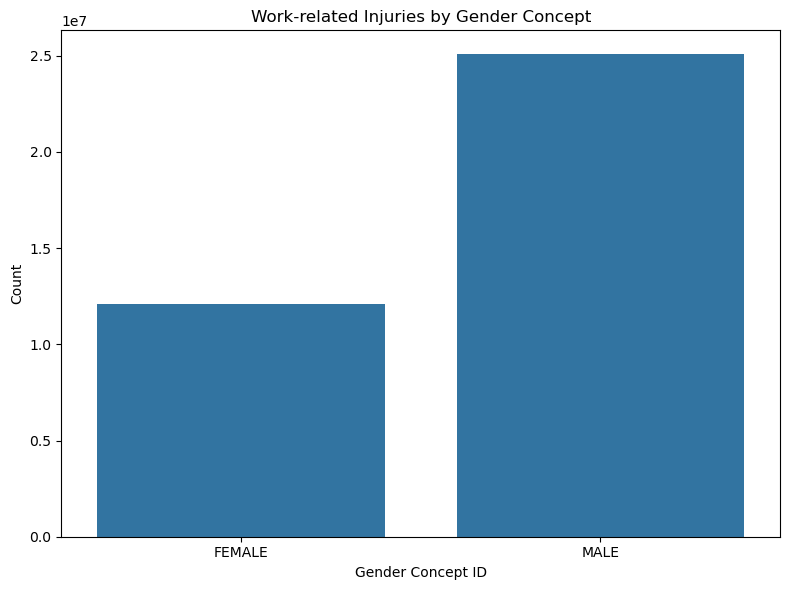

In [9]:
# Injuries by gender
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='gender', order=sorted(df['gender'].unique()))
plt.title('Work-related Injuries by Gender Concept')
plt.xlabel('Gender Concept ID')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

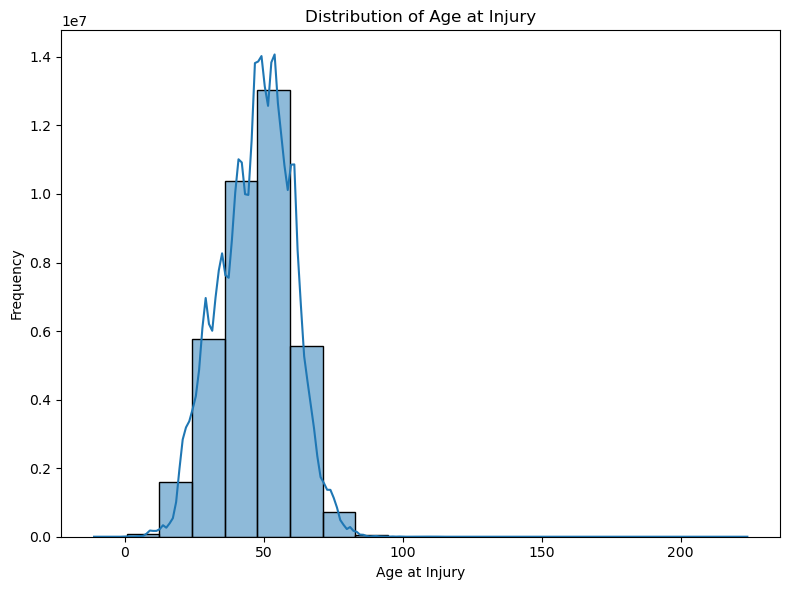

In [10]:
# Histogram of Age at Injury
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='age_at_injury', bins=20, kde=True)
plt.title('Distribution of Age at Injury')
plt.xlabel('Age at Injury')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

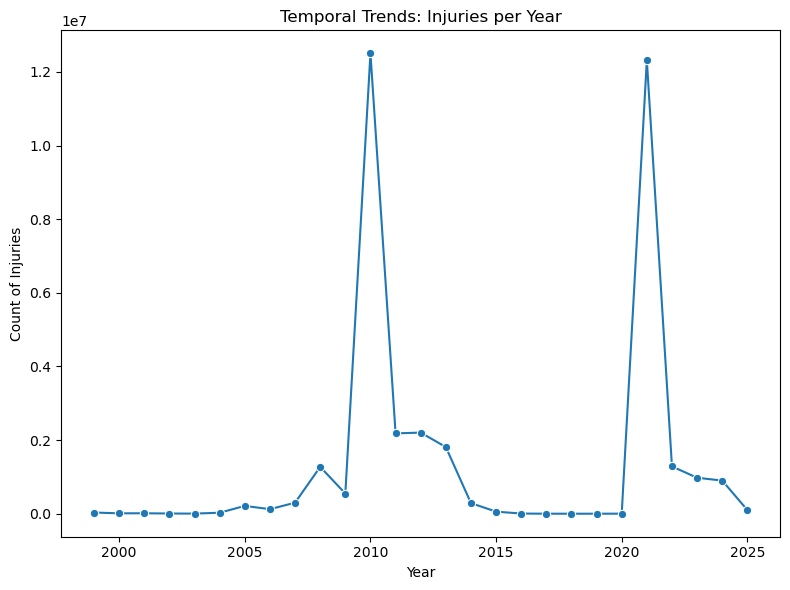

In [11]:
# Injuries per Year
year_counts = df['injury_year'].value_counts().sort_index().reset_index()
year_counts.columns = ['injury_year', 'count']
plt.figure(figsize=(8, 6))
sns.lineplot(data=year_counts, x='injury_year', y='count', marker="o")
plt.title('Temporal Trends: Injuries per Year')
plt.xlabel('Year')
plt.ylabel('Count of Injuries')
plt.tight_layout()
plt.show()

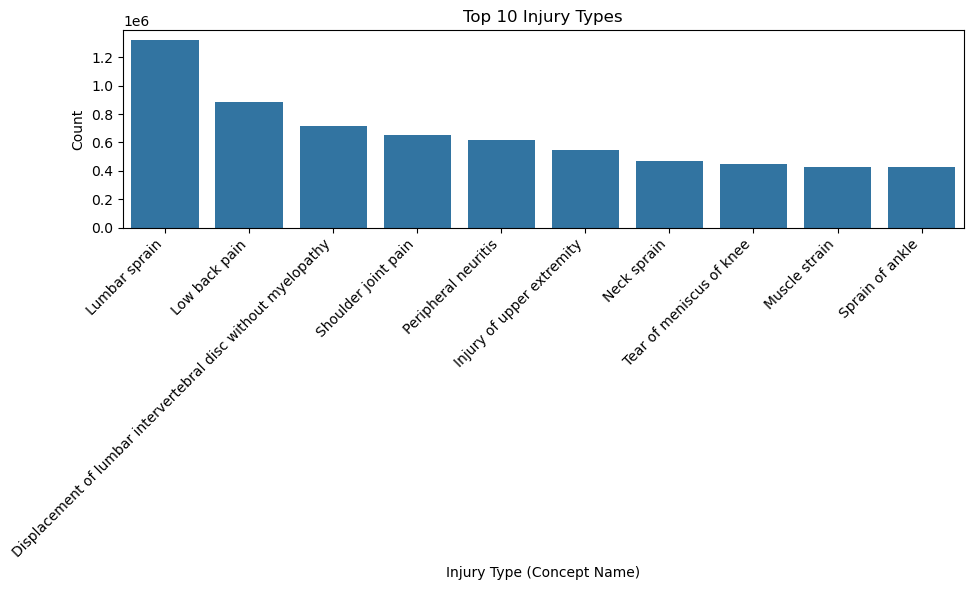

In [12]:
# Distribution of Injury Types
top_injury_types = df['concept_name'].value_counts().head(10).reset_index()
top_injury_types.columns = ['concept_name', 'count']
plt.figure(figsize=(10, 6))
sns.barplot(data=top_injury_types, x='concept_name', y='count')
plt.title('Top 10 Injury Types')
plt.xlabel('Injury Type (Concept Name)')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
conn.close()